In [20]:
import os
from typing import Annotated, TypedDict, Union, List
from azure.cosmos import CosmosClient, PartitionKey
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
import config
from dotenv import load_dotenv
load_dotenv()
# --- 1. Cosmos DB Configuration ---
# ENDPOINT = config.cosmos_url
# KEY = config.cosmos_key
KEY = os.getenv("cosmos_key")
ENDPOINT = os.getenv("cosmos_url")

DATABASE_NAME = "hgs-output"
CONTAINER_NAME = "route"

client = CosmosClient(ENDPOINT, KEY)
database = client.get_database_client(DATABASE_NAME)
container = database.get_container_client(CONTAINER_NAME)

# --- 2. Define the Tools ---
@tool
def get_container_schema():
    """Returns a sample document from the container to help the agent understand the schema."""
    try:
        # Fetch 1 document to see the structure
        items = list(container.query_items(
            query="SELECT TOP 1 * FROM c",
            enable_cross_partition_query=True
        ))
        if items:
            # We remove internal Azure fields to save tokens
            schema = {k: v for k, v in items[0].items() if not k.startswith('_')}
            return f"Sample document structure: {schema}"
        return "The container is empty."
    except Exception as e:
        return f"Error fetching schema: {str(e)}"

@tool
def query_cosmos_db(query: str):
    """
    Executes a SQL query against the Azure Cosmos DB NoSQL container.
    Example query: SELECT * FROM c WHERE c.category = 'electronics'
    """
    try:
        results = list(container.query_items(
            query=query,
            enable_cross_partition_query=True
        ))
        return results if results else "No results found."
    except Exception as e:
        return f"Query failed: {str(e)}"

tools = [get_container_schema, query_cosmos_db]
tool_node = ToolNode(tools)

# --- 3. Define the Graph State ---

class AgentState(TypedDict):
    # add_messages allows the state to append new messages rather than overwriting
    messages: Annotated[list[BaseMessage], add_messages]

# --- 4. Define the Nodes and Logic ---

# model = ChatOpenAI(model="gpt-4o", temperature=0).bind_tools(tools)

model = ChatOpenAI(
    model="gemini-2.5-flash",
    openai_api_key=config.gemini_key,
    openai_api_base="https://generativelanguage.googleapis.com/v1beta/openai/",
    temperature=0
).bind_tools(tools)


# Define a clear instruction for the AI
SYSTEM_PROMPT = SystemMessage(content=(
    "You are an expert Cosmos DB Data Assistant. "
    "When a user asks a question about data, you MUST first call 'get_container_schema' "
    "to understand the data structure. Do not ask the user for the schema; "
    "you have the tools to find it yourself. After you have the schema, "
    "generate a SQL query and use 'query_cosmos_db' to get the answer."
))

def call_model(state: AgentState):
    messages = state['messages']
    # Ensure the system prompt is always at the start of the conversation
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SYSTEM_PROMPT] + messages
    response = model.invoke(messages)
    return {"messages": [response]}

def should_continue(state: AgentState):
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "tools"
    return END

# --- 5. Build the Graph (Updated) ---

workflow = StateGraph(AgentState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")

# We add a mapping dictionary here so the graph 
# knows exactly where 'tools' and END lead.
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",  # If should_continue returns "tools", go to tools node
        END: END           # If should_continue returns END, go to __end__
    }
)

# The edge back from tools to agent
workflow.add_edge("tools", "agent")

app = workflow.compile()

# --- 6. Run the Agent ---

def ask_question(question: str):
    inputs = {"messages": [HumanMessage(content=question)]}
    for output in app.stream(inputs, stream_mode="values"):
        last_msg = output["messages"][-1]
        if last_msg.content:
            print(f"\nAI: {last_msg.content}")

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("cosmos_url")
print(api_key)

https://hgs-optimization.documents.azure.com:443/


In [21]:
ask_question("what is the maximum and average number of routes planned from all the data ? routes is the list that contains route id")


AI: what is the maximum and average number of routes planned from all the data ? routes is the list that contains route id

AI: Sample document structure: {'status': True, 'id': '005c0d41-20ef-4bcc-822b-6228428c579b', 'routes': [{'route_id': 0, 'vehicle_name': 'Double Decker (EU)', 'visits': [{'visit_name': 'Lifecycle Oils Haydock', 'directoryReference': 'cba41e87-21ba-4d5e-89dc-33347ab54075', 'orderIds': ['2c51d235-43d4-4e71-8741-638f6b122a26', 'bf5e281f-8f96-4dec-9ab5-168a5466bdb5', 'ecbc5712-3701-4cd0-92da-9d9caa44153d', '4b67d7ad-ffe5-4bb3-aeda-0810208b1bc0', 'b7fbd5e9-2ffb-452e-a193-527e10d55ea3', '3688702e-3afd-4cad-aa5d-bf82094da168', '6ad80e69-c30d-47fc-a61d-7da5312cc85f', 'fdf7aacd-d066-406d-add8-1d2ddfae5e7b', '38201b2e-6b9d-442c-ba7b-a1167a02bb15', 'b40143f9-79d9-4d5b-8684-4e68e4eac837', '700098a4-45a3-4576-9d10-75ab4acb9d49'], 'order_number': ['SPFleet112', 'SPFleet134', 'SPFleet144', 'SPFleet145', 'SPFleet153', 'SPFleet115', 'SPFleet116', 'SPFleet118', 'SPFleet114', 'SPFl

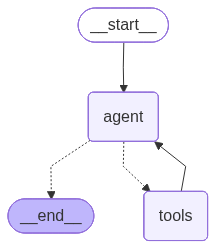

In [9]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))